In [15]:
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import STL
import logging
import os
from concurrent.futures import ThreadPoolExecutor
from functools import partial
from IPython.display import display
from sklearn.neighbors import NearestNeighbors


logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

In [16]:

uuid_stats_logger = logging.getLogger('uuid_stats')
uuid_stats_logger.setLevel(logging.INFO)
file_handler = logging.FileHandler('log.txt', mode='w')
file_handler.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
uuid_stats_logger.addHandler(file_handler)
uuid_stats_logger.propagate = False

class TimeSeriesAnalyzer:
    def __init__(self, target_column='A_plus', period=24):
        # period -  период сезонности24 час
        self.target_column = target_column
        self.period = period
        self.graphics_dir = 'graphics'
        os.makedirs(self.graphics_dir, exist_ok=True)

    def statistical_summary(self, df, groupby='uuid'):
        # mean: μ = (1/n) * Σ y_t
        # std: σ = sqrt((1/n) * Σ (y_t - μ)^2)
        # missing_ratio: (число пропусков) / n
        stats = {
            'mean': df[self.target_column].mean(),
            'std': df[self.target_column].std(),
            'min': df[self.target_column].min(),
            'max': df[self.target_column].max(),
            'missing_ratio': df[self.target_column].isna().mean()
        }
        for key, value in stats.items():
            logging.info(f"{key}: {value}")

        for group in df[groupby].unique():
            group_data = df[df[groupby] == group][self.target_column]
            uuid_stats_logger.info(f"uuid_{group}_mean: {group_data.mean()}")
            uuid_stats_logger.info(f"uuid_{group}_std: {group_data.std()}")

    def plot_time_series(self, df, groupby='uuid'):
        plt.figure(figsize=(15, 7))
        for group in df[groupby].unique()[:5]:
            group_data = df[df[groupby] == group]
            plt.plot(group_data['time_dt'], group_data[self.target_column], label=f'uuid_{group}')
        plt.xlabel('Time')
        plt.ylabel(self.target_column)
        plt.title('Time Series by UUID')
        plt.legend()
        plt.grid(True)
        plt.savefig(os.path.join(self.graphics_dir, 'time_series_plot.png'))
        plt.close()

    def plot_distribution(self, df):
        plt.figure(figsize=(10, 6))
        df[self.target_column].hist(bins=50)
        plt.title(f'Distribution of {self.target_column}')
        plt.xlabel(self.target_column)
        plt.ylabel('Frequency')
        plt.grid(True)
        plt.savefig(os.path.join(self.graphics_dir, 'distribution_plot.png'))
        plt.close()

    def plot_stl_decomposition(self, df, groupby='uuid'):
        # STL-разложение: y_t = T_t + S_t + R_t
        # T_t: тренд, S_t: сезонная компонента, R_t: остатки
        # LOESS с весами: W(u) = (1 - |u|^3)^3, u = |t_i - t| / Δ
        for group in df[groupby].unique()[:5]:
            group_data = df[df[groupby] == group][self.target_column]
            if len(group_data) > self.period:
                stl = STL(group_data, period=self.period) # Пока что либой TODO
                result = stl.fit()
                
                plt.figure(figsize=(10, 8))
                plt.subplot(4, 1, 1)
                plt.plot(group_data, label='Original')
                plt.title(f'STL Decomposition for uuid_{group}')
                plt.legend()
                
                plt.subplot(4, 1, 2)
                plt.plot(result.trend, label='Trend (T_t)')
                plt.legend()
                
                plt.subplot(4, 1, 3)
                plt.plot(result.seasonal, label='Seasonal (S_t)')
                plt.legend()
                
                plt.subplot(4, 1, 4)
                plt.plot(result.resid, label='Residuals (R_t)')
                plt.legend()
                
                plt.tight_layout()
                plt.savefig(os.path.join(self.graphics_dir, f'stl_decomposition_{group}.png'))
                plt.close()

    def analyze(self, df, groupby='uuid'):
        logging.info("Начало анализа временных рядов")
        
        if df[self.target_column].isna().sum() > 0:
            logging.warning(f"Обнаружены пропуски в {self.target_column}: {df[self.target_column].isna().sum()}")
        
        logging.info("Статистический анализ:")
        self.statistical_summary(df, groupby)
        
        self.plot_time_series(df, groupby)
        self.plot_distribution(df)
        self.plot_stl_decomposition(df, groupby)
        
        logging.info("Анализ временных рядов завершен")

In [17]:

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class MissingValueHandler:
    def __init__(self, method='linear'):
        # method: метод заполнения пропусков
        # Доступные методы
        # - linear: Линейная интерполяция, y_t = y_(t-k) + (y_(t+m) - y_(t-k)) * (t - (t-k)) / (m + k)
        # - seasonal: Сезонная интерполяция, y_t = (1/n) * Σ y_(t-24i)
        # - knn: KNN-восстановление, y_t = Σ (w_i * y_i), w_i = (1/d(t, t_i)) / Σ (1/d(t, t_j))
        self.method = method
        if method not in ['linear', 'seasonal', 'knn']:
            raise ValueError("Метод должен быть 'linear', 'seasonal' или 'knn'")

    def _linear_interpolation(self, series, indices):
        interpolated = series.copy()
        for idx in indices:
            prev_idx = next((i for i in range(idx-1, -1, -1) if not np.isnan(series[i])), None)
            next_idx = next((i for i in range(idx+1, len(series)) if not np.isnan(series[i])), None)
            if prev_idx is not None and next_idx is not None:
                y_prev, y_next = series[prev_idx], series[next_idx]
                t_prev, t_next = prev_idx, next_idx
                t = idx
                interpolated[idx] = y_prev + (y_next - y_prev) * (t - t_prev) / (t_next - t_prev)
        return interpolated

    def _knn_imputation(self, df, column, groupby, time_column, k=5):
        df_copy = df.copy()
        for group in df_copy[groupby].unique():
            group_data = df_copy[df_copy[groupby] == group]
            mask = group_data[column].isna()
            if mask.any():
                valid_data = group_data[~mask]
                missing_data = group_data[mask]
                if len(valid_data) < k:
                    logging.warning(f"Недостаточно данных для KNN (uuid={group}) Заполненим средним") 
                    df_copy.loc[mask, column] = valid_data[column].mean() if valid_data[column].notna().any() else 0
                    continue
                X_valid = (valid_data[time_column] - valid_data[time_column].min()).dt.total_seconds().values.reshape(-1, 1)
                X_missing = (missing_data[time_column] - valid_data[time_column].min()).dt.total_seconds().values.reshape(-1, 1)
                y_valid = valid_data[column].values
                knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
                knn.fit(X_valid)
                distances, indices = knn.kneighbors(X_missing) # TODO
                for i, idx in enumerate(missing_data.index):
                    weights = 1 / (distances[i] + 1e-10)
                    weights /= weights.sum()
                    df_copy.loc[idx, column] = np.sum(weights * y_valid[indices[i]])
        return df_copy
    # 
    def _clean_outliers(self, series):
        valid_data = series.dropna()
        if len(valid_data) > 0:
            q1, q3 = valid_data.quantile([0.25, 0.75])
            iqr = q3 - q1
            lower_bound = q1 - 1.5 * iqr
            upper_bound = q3 + 1.5 * iqr
            return series.clip(lower=lower_bound, upper=upper_bound)
        return series

    def handle(self, df, column, groupby='uuid', time_column='time_dt'):
        # Пропуски - это отсутствие строки для ожидаемого часа
        # Добавление временных меток, затем заполнение пропусков
        if column not in df.columns or time_column not in df.columns or groupby not in df.columns:
            raise ValueError("Указанные столбцы отсутствуют в данных")
        
        df_copy = df.copy()
        all_data = []
        for group in df_copy[groupby].unique():
            group_data = df_copy[df_copy[groupby] == group]
            if group_data[time_column].isna().any():
                logging.warning(f"Обнаружены пропуски в {time_column} для uuid={group}")
                continue
            min_time = group_data[time_column].min()
            max_time = group_data[time_column].max()
            if pd.isna(min_time) or pd.isna(max_time):
                logging.warning(f"Некорректные временные метки для uuid={group}. Пропуск группы.")
                continue
            full_time_index = pd.date_range(start=min_time, end=max_time, freq='h')
            full_df = pd.DataFrame({time_column: full_time_index, groupby: group})
            merged_df = full_df.merge(group_data, on=[groupby, time_column], how='left')
            all_data.append(merged_df)
        
        if not all_data:
            raise ValueError("Нет данных для обработки после проверки временных меток")
        
        df_copy = pd.concat(all_data, ignore_index=True)
        missing_count = df_copy[column].isna().sum()
        logging.info(f"Обнаружено {missing_count} пропусков (отсутствующих строк) в {column}")
        
        if missing_count > 0:
            # Очистка выбросов перед интерполяцией --- ??? пока пусть будет
            # df_copy[column] = df_copy.groupby(groupby)[column].transform(self._clean_outliers)
            
            if self.method == 'seasonal':
                # Сезонная интерполяция y_t = (1/n) * Σ y_(t-24i)
                df_copy['hour'] = df_copy[time_column].dt.hour
                for group in df_copy[groupby].unique():
                    group_mask = df_copy[groupby] == group
                    missing_hours = df_copy[group_mask & df_copy[column].isna()]['hour'].unique()
                    for hour in missing_hours:
                        mask = group_mask & (df_copy['hour'] == hour) & (df_copy[column].isna())
                        seasonal_values = df_copy[group_mask & (df_copy['hour'] == hour)][column]
                        valid_count = seasonal_values.notna().sum()
                        if valid_count >= 3:  # Требуется минимум 3 значения
                            seasonal_mean = seasonal_values.mean()
                            df_copy.loc[mask, column] = seasonal_mean
                        else:
                            logging.warning(f"Недостаточно данных для часа {hour} в uuid {group} ({valid_count} значений)")
                            df_copy.loc[mask, column] = np.nan
                    df_copy.loc[group_mask, column] = df_copy.loc[group_mask, column].interpolate(method='linear').bfill().ffill()
                df_copy = df_copy.drop(columns=['hour'])
            elif self.method == 'knn':  
                df_copy = self._knn_imputation(df_copy, column, groupby, time_column, k=5)
            else:
                for group in df_copy[groupby].unique():
                    group_mask = df_copy[groupby] == group
                    series = df_copy.loc[group_mask, column].values
                    indices = df_copy.loc[group_mask & df_copy[column].isna()].index
                    if len(indices) > 0:
                        interpolated = self._linear_interpolation(series, indices)
                        df_copy.loc[group_mask, column] = interpolated
                df_copy[column] = df_copy.groupby(groupby)[column].transform(lambda x: x.fillna(x.mean() if x.notna().any() else 0))
        
        for col in ['A_minus', 'R_plus', 'R_minus']:
            if col in df_copy.columns:
                df_copy[col] = df_copy.groupby(groupby)[col].transform(
                    lambda x: x.fillna(x.median() if x.notna().any() else x.min() if x.notna().any() else 0)
                )
        
        if missing_count > 0:
            mae = np.abs(df_copy[column] - df_copy[column].interpolate(method='linear')).mean()
            variance = df_copy[column].var()
            logging.info(f"дисперсия ряда: {variance:.4f}")

        logging.info(f"Обнаружено {df_copy[column].isna().sum()} пропусков в {column} после заполнения")
        return df_copy

In [18]:
 
log = logging.getLogger('anomaly')
log.setLevel(logging.INFO)
h = logging.FileHandler('anomalies.log', mode='a')
h.setFormatter(logging.Formatter('%(asctime)s - %(levelname)s - %(message)s'))
log.addHandler(h)
log.propagate = False

class AnomalyFix:
    def __init__(self, method='stl', action='interpolate', thresh=2.5, win=13):
        # method: как искать аномалии
        # - stl: STL, |R_t| > k * σ_R
        # - lstm: LSTM (не сделано)
        # action: что делать
        # - interpolate: линейно
        # - remove: убрать
        self.method = method
        self.action = action
        self.thresh = thresh
        self.win = win
        if method not in ['stl', 'lstm']:
            raise ValueError("Метод: 'stl' или 'lstm'")
        if action not in ['interpolate', 'remove']:
            raise ValueError("Действие: 'interpolate' или 'remove'")

    def _smooth(self, y, x, win, deg=1, robust=False, max_iter=1):
        # Сглаживание: W(u) = (1 - |u|^3)^3
        n = len(y)
        out = np.zeros(n)
        for i in range(n):
            dist = np.abs(x - x[i])
            idx = np.argsort(dist)[:win]
            d = dist[idx]
            h = d[-1] if d.size > 0 else 1.0
            w = (1 - (d / (h + 1e-10)) ** 3) ** 3
            
            if robust:
                for _ in range(max_iter):
                    X = np.vstack([np.ones(len(idx)), x[idx] - x[i]]).T
                    W = np.diag(w)
                    try:
                        b = np.linalg.lstsq(X.T @ W @ X, X.T @ W @ y[idx], rcond=None)[0]
                        out[i] = b[0]
                    except np.linalg.LinAlgError:
                        out[i] = y[i]
                        break
                    res = y[idx] - X @ b
                    mad = np.median(np.abs(res))
                    if mad == 0:
                        break
                    w *= np.clip(6 * mad / (np.abs(res) + 1e-10), 0, 1)
            else:
                X = np.vstack([np.ones(len(idx)), x[idx] - x[i]]).T
                W = np.diag(w)
                try:
                    b = np.linalg.lstsq(X.T @ W @ X, X.T @ W @ y[idx], rcond=None)[0]
                    out[i] = b[0]
                except np.linalg.LinAlgError:
                    out[i] = y[i]
        return out

    def _stl(self, data, period=24, s_win=7, t_win=49, iters=2):
        # Разложение: y_t = T_t + S_t + R_t
        y = data.values
        n = len(y)
        x = np.arange(n)
        trend = np.zeros(n)
        season = np.zeros(n)
        resid = np.zeros(n)
        
        for i in range(iters):
            robust = (i == iters - 1)
            det = y - season
            trend = self._smooth(det, x, win=t_win, robust=robust)   
            cycle = y - trend
            season = np.zeros(n)
            for p in range(period):
                idx = np.arange(p, n, period)
                if len(idx) > 0:
                    sub = cycle[idx]
                    sub_x = np.arange(len(sub))
                    season[idx] = self._smooth(sub, sub_x, win=s_win, robust=robust)   
            resid = y - trend - season
        
        return {'trend': trend, 'season': season, 'resid': resid}

    def _interp(self, data, mask):
        out = data.copy()
        idx = np.where(mask)[0]
        for i in idx:
            prev = next((j for j in range(i-1, -1, -1) if not mask[j] and not np.isnan(data[j])), None)
            next_i = next((j for j in range(i+1, len(data)) if not mask[j] and not np.isnan(data[j])), None)
            if prev is not None and next_i is not None:
                y1, y2 = data[prev], data[next_i]
                t1, t2 = prev, next_i
                t = i
                out[i] = y1 + (y2 - y1) * (t - t1) / (t2 - t1)
        return out

    def _clean(self, data):
        if data.isna().any():
            valid = data.dropna()
            if len(valid) > 0:
                q1, q3 = valid.quantile([0.25, 0.75])
                iqr = q3 - q1
                low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
                data = data.clip(lower=low, upper=high)
            data = data.interpolate(method='linear').bfill().ffill()
        return data

    def _check(self, data):
        if data.isna().any():
            return False, "Есть пропуски"
        if data.var() < 1e-10:
            return False, "Дисперсия почти 0"
        diff = data.diff().abs()
        if diff.max() > data.std() * 5:
            return False, f"Скачки: {diff.max():.2f} > {data.std():.2f}"
        return True, ""

    def _proc(self, group, df, col, groupby):
        logging.info(f"STL для {group}")
        mask = df[groupby] == group
        data = df.loc[mask, col]
        result = {'mask': mask, 'anomaly': None, 'fixed': None, 'err': None}
        
        if len(data) > 2 * 24 and data.notna().sum() > 2 * 24:
            try:
                clean = self._clean(data)
                q1, q3 = clean.quantile([0.25, 0.75])
                iqr = q3 - q1
                clean = clean.clip(lower=q1 - 1.5 * iqr, upper=q3 + 1.5 * iqr)
                ok, msg = self._check(clean)
                if not ok:
                    result['err'] = f"Пропуск: {msg}"
                    return result
                stl = self._stl(clean, period=24, s_win=7, t_win=49)
                res = stl['resid']
                anomaly = np.abs(res) > self.thresh * np.std(res)
                
                result['anomaly'] = anomaly
                if anomaly.any():
                    times = df.loc[mask, 'time_dt'][anomaly]
                    log.info(f"Аномалий: {anomaly.sum()} для {group}")
                    for t, v in zip(times, data[anomaly]):
                        log.info(f"Аномалия: {group}, {t}, A_plus={v}")
                
                if self.action == 'interpolate':
                    result['fixed'] = self._interp(data.values, anomaly)
                elif self.action == 'remove':
                    result['remove'] = ~anomaly
            except Exception as e:
                result['err'] = f"Ошибка STL: {str(e)}"
        else:
            result['err'] = f"Мало данных: {len(data)}"
        
        logging.info(f"Размер для {group}: {len(data)}")
        return result

    def fix(self, df, col, groupby='uuid'):
        logging.info("Чищу аномалии")
        df_out = df.copy()
        df_out['anomaly'] = False
        total = 0
        
        with ThreadPoolExecutor() as ex:
            proc = partial(self._proc, df=df_out, col=col, groupby=groupby)
            results = list(ex.map(proc, df_out[groupby].unique()))
        
        for group, result in zip(df_out[groupby].unique(), results):
            if result['err']:
                logging.warning(f"{group}: {result['err']}")
                logging.info(f"Диагноз: NaN={df_out[df_out[groupby] == group][col].isna().sum()}, "
                            f"Inf={np.isinf(df_out[df_out[groupby] == group][col]).sum()}, "
                            f"Var={df_out[df_out[groupby] == group][col].var()}, "
                            f"Min={df_out[df_out[groupby] == group][col].min()}, "
                            f"Max={df_out[df_out[groupby] == group][col].max()}")
                continue
            
            mask = result['mask']
            if result['anomaly'] is not None:
                df_out.loc[mask, 'anomaly'] = result['anomaly']
                total += result['anomaly'].sum()
                
                if self.action == 'interpolate' and result['fixed'] is not None:
                    df_out.loc[mask, col] = result['fixed']
                    df_out.loc[mask, col] = df_out.loc[mask, col].fillna(
                        df_out.loc[mask, col].mean() if df_out.loc[mask, col].notna().any() else 0)
                elif self.action == 'remove' and 'remove' in result:
                    df_out = df_out.loc[~((df_out[groupby] == group) & ~result['remove'])]
        
        if total > 0:
            mae = np.abs(df_out[col] - df_out[col].interpolate(method='linear')).mean()
            rmse = np.sqrt(((df_out[col] - df_out[col].interpolate(method='linear')) ** 2).mean())
            logging.info(f"MAE: {mae:.4f}, RMSE: {rmse:.4f}")
        
        logging.info(f"Всего аномалий: {total}")
        return df_out

In [19]:

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class NormFix:
    def __init__(self, method='standardize'):
        # Выбор метода нормализации
        # - standardize: (y - μ) / σ
        # - log: log(y + 1)
        # - user_standardize: по группам
        self.method = method
        if method not in ['standardize', 'log', 'user_standardize']:
            raise ValueError("Метод: 'standardize', 'log' или 'user_standardize'")

    def _check(self, df, col, group):
        if col not in df.columns:
            raise ValueError(f"Нет столбца {col}")
        if group not in df.columns:
            raise ValueError(f"Нет столбца группировки {group}")
        if df[col].isna().any():
            logging.warning(f"Пропуски в {col}: {df[col].isna().sum()}")

    def fix(self, df, col, group='uuid'):
        df_out = df.copy()
 
        self._check(df_out, col, group)
        
 
        logging.info(f"До: mean={df_out[col].mean():.4f}, std={df_out[col].std():.4f}")
        
        if self.method == 'log':
            # Логарифм: log(y + 1)
            if (df_out[col] + 1 <= 0).any():
                logging.warning("Есть y + 1 <= 0, беру abs.")
                df_out[col] = np.log(np.abs(df_out[col]) + 1)
            else:
                df_out[col] = np.log(df_out[col] + 1)
        elif self.method == 'user_standardize':
            def norm_group(x):
                if x.notna().sum() < 2:
                    logging.warning(f"Мало данных для группы {x.name}. Ставлю нули.")
                    return np.zeros_like(x)
                if x.std() == 0:
                    logging.warning(f"Дисперсия 0 для группы {x.name}. Ставлю нули.")
                    return np.zeros_like(x)
                return (x - x.mean()) / x.std()
            df_out[col] = df_out.groupby(group)[col].transform(norm_group)
        else:
            # Обычная нормализация: (y - μ) / σ
            if df_out[col].std() == 0:
                logging.warning("Дисперсия 0. Ставлю нули.")
                df_out[col] = np.zeros_like(df_out[col])
            else:
                df_out[col] = (df_out[col] - df_out[col].mean()) / df_out[col].std()
        
        logging.info(f"После: mean={df_out[col].mean():.4f}, std={df_out[col].std():.4f}")
        
 
        if self.method != 'log':
            if abs(df_out[col].mean()) > 1e-10 or abs(df_out[col].std() - 1) > 1e-10:
                logging.warning("Среднее не 0 или std не 1.")
        
        return df_out


In [20]:
 

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

class DataPrep:
    def __init__(self, miss_method='linear', anom_method='stl', anom_act='interpolate', norm_method='standardize'):
        # miss_method: как чинить пропуски
        # - linear: линейно
        # - seasonal: y_t = (1/n) * Σ y_(t-24i)
        # - knn: по ближайшим
        # anom_method: как искать аномалии
        # - stl: |R_t| > k * σ_R
        # - lstm: не сделано
        # anom_act: что делать
        # - interpolate: линейно
        # - remove: убрать
        # norm_method: нормализация
        # - standardize: (y - μ) / σ
        # - log: log(y + 1)
        # - user_standardize: по группам
        valid_miss = ['linear', 'seasonal', 'knn']
        valid_anom = ['stl', 'lstm']
        valid_act = ['interpolate', 'remove']
        valid_norm = ['standardize', 'log', 'user_standardize']
        if miss_method not in valid_miss:
            raise ValueError(f"miss_method: {valid_miss}")
        if anom_method not in valid_anom:
            raise ValueError(f"anom_method: {valid_anom}")
        if anom_act not in valid_act:
            raise ValueError(f"anom_act: {valid_act}")
        if norm_method not in valid_norm:
            raise ValueError(f"norm_method: {valid_norm}")
        
        self.miss_fix = MissingValueHandler(method=miss_method)
        self.anom_fix = AnomalyFix(method=anom_method, action=anom_act)
 
        self.norm_fix = NormFix(method=norm_method)
        self.graph_dir = 'graphics'
        os.makedirs(self.graph_dir, exist_ok=True)
        self.stats = []

    def _check(self, df, col, group, time_col='time_dt'):
        req_cols = [col, group, time_col]
        miss_cols = [c for c in req_cols if c not in df.columns]
        if miss_cols:
            raise ValueError(f"Нет столбцов: {miss_cols}")
        if df[col].isna().all():
            raise ValueError(f"Все в {col} пусто")
        if df[time_col].isna().any():
            raise ValueError(f"Пропуски в {time_col}")

    def _stats(self, df, col, stage):
        try:
            stats = {
                'stage': stage,
                'mean': df[col].mean() if df[col].notna().any() else np.nan,
                'std': df[col].std() if df[col].notna().any() else np.nan,
                'min': df[col].min() if df[col].notna().any() else np.nan,
                'max': df[col].max() if df[col].notna().any() else np.nan,
                'missing_ratio': df[col].isna().mean(),
                'q25': df[col].quantile(0.25) if df[col].notna().any() else np.nan,
                'q50': df[col].quantile(0.50) if df[col].notna().any() else np.nan,
                'q75': df[col].quantile(0.75) if df[col].notna().any() else np.nan
            }
            self.stats.append(stats)
            return stats
        except Exception as e:
            logging.error(f"Ошибка в {stage}: {str(e)}")
            return None

    def _plot_dist(self, df, col, stage):
        try:
            data = df[col].dropna()
            if len(data) > 0:
                plt.figure(figsize=(10, 6))
                data.hist(bins=50, density=True)
                plt.title(f'{col} ({stage})')
                plt.xlabel(col)
                plt.ylabel('Density')
                plt.grid(True)
                plt.savefig(os.path.join(self.graph_dir, f'dist_{stage.replace(" ", "_").lower()}.png'))
                plt.close()
            else:
                logging.warning(f"Нет данных для {stage}")
        except Exception as e:
            logging.error(f"Ошибка графика {stage}: {str(e)}")

    def _plot_time(self, dfs, labels, col, group, uuid):
        try:
            plt.figure(figsize=(15, 7))
            for df, lab in zip(dfs, labels):
                grp_data = df[df[group] == uuid]
                if grp_data[col].notna().any():
                    plt.plot(grp_data['time_dt'], grp_data[col], label=lab, alpha=0.7)
            plt.xlabel('Time')
            plt.ylabel(col)
            plt.title(f'Time Comp for {uuid}')
            plt.legend()
            plt.grid(True)
            plt.gca().xaxis.set_major_formatter(plt.dates.DateFormatter('%Y-%m-%d %H:%M'))
            plt.gcf().autofmt_xdate()
            plt.savefig(os.path.join(self.graph_dir, f'time_comp_{uuid}.png'))
            plt.close()
        except Exception as e:
            logging.error(f"Ошибка для {uuid}: {str(e)}")

    def _plot_dist_comp(self, dfs, labels, col):
        try:
            plt.figure(figsize=(10, 6))
            for df, lab in zip(dfs, labels):
                data = df[col].dropna()
                if len(data) > 0:
                    data.hist(bins=50, alpha=0.5, label=lab, density=True)
            plt.title(f'{col} Comparison')
            plt.xlabel(col)
            plt.ylabel('Density')
            plt.legend()
            plt.grid(True)
            plt.savefig(os.path.join(self.graph_dir, 'dist_comp.png'))
            plt.close()
        except Exception as e:
            logging.error(f"Ошибка: {str(e)}")

    def prep(self, df, target, group='uuid'):
        logging.info("Старт обработки")
        self._check(df, target, group)
        
        df_out = df.copy()
        dfs = [df_out]
        stages = ['исходные']
        
        self._stats(df_out, target, 'исходные')
        self._plot_dist(df_out, target, 'исходные')
        
        logging.info("Чищу пропуски")
        df_out = self.miss_fix.handle(df_out, target, groupby=group)
        if df_out[target].isna().any():
            logging.warning(f"Остались пропуски: {df_out[target].isna().sum()}")
        dfs.append(df_out.copy())
        stages.append('после пропусков')
        self._stats(df_out, target, 'после пропусков')
        self._plot_dist(df_out, target, 'после пропусков')
        
        logging.info("Чищу аномалии")
        df_out = self.anom_fix.fix(df_out, target, groupby=group)
        dfs.append(df_out.copy())
        stages.append('после аномалий')
        self._stats(df_out, target, 'после аномалий')
        self._plot_dist(df_out, target, 'после аномалий')
        
        logging.info("Нормализую")
        df_out = self.norm_fix.fix(df_out, target, group=group)   
        dfs.append(df_out.copy())
        stages.append('после нормализации')
        self._stats(df_out, target, 'после нормализации')
        self._plot_dist(df_out, target, 'после нормализации')
        
        uuid_count = df[group].value_counts()
        top_uuid = uuid_count.idxmax() if not uuid_count.empty else df[group].unique()[0]
        self._plot_time(dfs, stages, target, group, top_uuid)
        self._plot_dist_comp(dfs, stages, target)
        
        stats_df = pd.DataFrame(self.stats)
        if not stats_df.empty:
            stats_df = stats_df.set_index('stage')
            logging.info("Статистика")
            logging.info(f"\n{stats_df.to_string()}")
            print("Статистика")
            display(stats_df)
        else:
            logging.warning("Статистика пустая")
        
        logging.info("Готово, успех!")
        return df_out

2025-05-11 16:31:14,792 - INFO - data/file2.csv
2025-05-11 16:31:14,876 - INFO - Столбцы: ['uuid', 'time_dt', 'A_plus', 'A_minus', 'R_plus', 'R_minus']
2025-05-11 16:31:14,879 - INFO - Первые 5 строк:
                                   uuid              time_dt  A_plus  A_minus  R_plus  R_minus
0  03014b53-9900-4d9a-b78c-2959d439a8eb  2023-11-23 00:00:00  372.26      0.0   95.89     2.66
1  03014b53-9900-4d9a-b78c-2959d439a8eb  2023-11-23 01:00:00  271.50      0.0   13.22     8.70
2  03014b53-9900-4d9a-b78c-2959d439a8eb  2023-11-23 02:00:00  322.82      0.0   74.21     0.04
3  03014b53-9900-4d9a-b78c-2959d439a8eb  2023-11-23 03:00:00  215.03      0.0   21.04     3.63
4  03014b53-9900-4d9a-b78c-2959d439a8eb  2023-11-23 04:00:00  421.86      0.0   94.25     1.03
2025-05-11 16:31:14,897 - INFO - Анализ рядов
2025-05-11 16:31:14,897 - INFO - Начало анализа временных рядов
2025-05-11 16:31:14,898 - INFO - Статистический анализ:
2025-05-11 16:31:14,900 - INFO - mean: 194.83411370991467
2025-

Статистика


,mean,std,min,max,missing_ratio,q25,q50,q75
stage,,,,,,,,
исходные,1.948341e+02,183.035346,0.000000,2325.370000,0.0,93.700000,139.860000,230.75250
после пропусков,1.949510e+02,173.843185,0.000000,2325.370000,0.0,100.022191,143.840000,232.51000
после аномалий,1.893333e+02,160.716297,0.000000,2325.370000,0.0,100.280000,143.440000,229.35000
после нормализации,-4.289889e-17,1.000000,-1.178059,13.290729,0.0,-0.554102,-0.285555,0.24899


2025-05-11 16:32:02,006 - INFO - Готово, успех!
2025-05-11 16:32:02,008 - INFO - Первые строки результата


              time_dt                                  uuid    A_plus  \
0 2023-11-23 00:00:00  03014b53-9900-4d9a-b78c-2959d439a8eb  1.138196   
1 2023-11-23 01:00:00  03014b53-9900-4d9a-b78c-2959d439a8eb  0.511253   
2 2023-11-23 02:00:00  03014b53-9900-4d9a-b78c-2959d439a8eb  0.830574   
3 2023-11-23 03:00:00  03014b53-9900-4d9a-b78c-2959d439a8eb  0.159889   
4 2023-11-23 04:00:00  03014b53-9900-4d9a-b78c-2959d439a8eb  1.446815   

   A_minus  R_plus  R_minus  anomaly  
0      0.0   95.89     2.66    False  
1      0.0   13.22     8.70    False  
2      0.0   74.21     0.04    False  
3      0.0   21.04     3.63    False  
4      0.0   94.25     1.03    False  


2025-05-11 16:32:02,492 - INFO - Сохранено в clean_data.csv


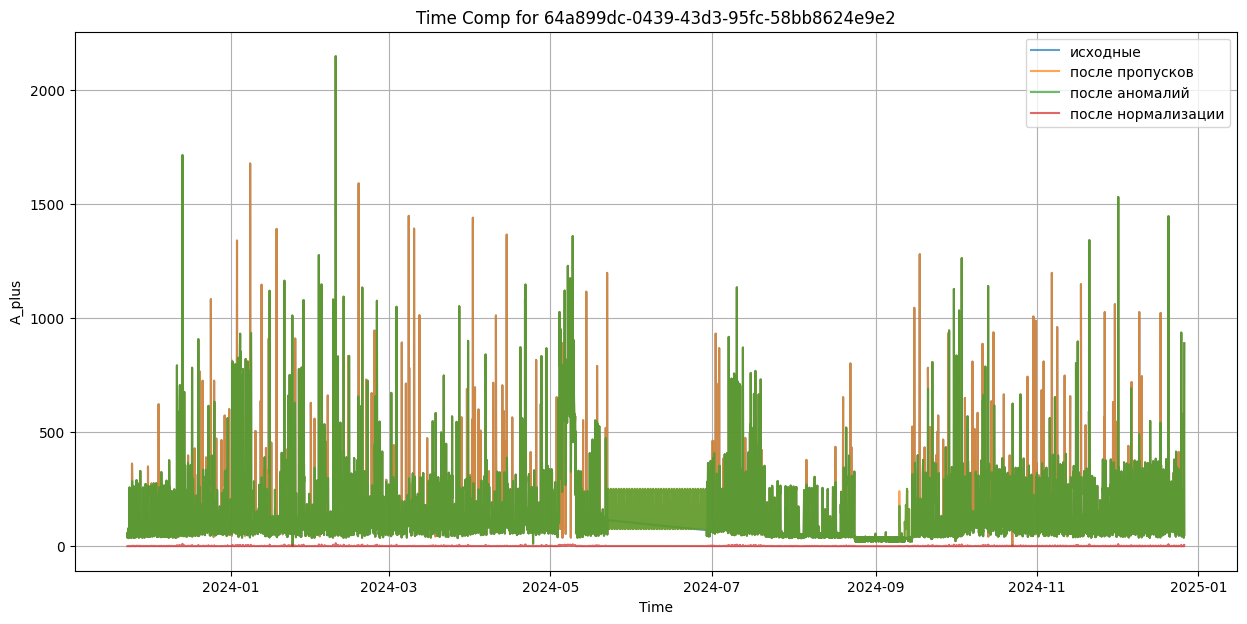

In [21]:


logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')

 
try:
    # file = 'data/207_hour_energy.csv'
    file = 'data/file2.csv'
    logging.info(f"{file}")
    if not os.path.exists(file):
        raise FileNotFoundError(f"Нет файла {file}")
    data = pd.read_csv(file, sep='\t')
except Exception as e:
    logging.error(f"Ошибка загрузки: {str(e)}")
    raise

need_cols = ['time_dt', 'A_plus', 'uuid']
miss_cols = [c for c in need_cols if c not in data.columns]
if miss_cols:
    raise KeyError(f"Нет столбцов: {miss_cols}. Есть: {data.columns.tolist()}")

logging.info(f"Столбцы: {data.columns.tolist()}")
logging.info(f"Первые 5 строк:\n{data.head().to_string()}")

 
time_col = 'time_dt'
try:
    data[time_col] = pd.to_datetime(data[time_col], errors='raise')
except Exception as e:
    logging.error(f"Ошибка с {time_col}: {str(e)}")
    raise

 
if data.empty:
    raise ValueError("Пусто, ничего нет")

 
try:
    analyzer = TimeSeriesAnalyzer(target_column='A_plus', period=24)
    logging.info("Анализ рядов")
    analyzer.analyze(data, groupby='uuid')
except Exception as e:
    logging.error(f"Ошибка анализа: {str(e)}")
    raise

try:
    prep = DataPrep(
        miss_method='seasonal',
        anom_method='stl',
        anom_act='interpolate',
        norm_method='standardize'
    )
    logging.info("Старт обработки")
    clean_data = prep.prep(data, target='A_plus', group='uuid')
except Exception as e:
    logging.error(f"Ошибка обработки: {str(e)}")
    raise


try:
    logging.info("Первые строки результата")
    print(clean_data.head())
    
    out_file = 'clean_data.csv'
    clean_data.to_csv(out_file, index=False)
    logging.info(f"Сохранено в {out_file}")
except Exception as e:
    logging.error(f"Ошибка сохранения: {str(e)}")
    raise